# Study 786 — Flu-Season 🤧

*For the curious.* Everyone *knows* you buy the drugstores into flu season — CVS gets bid up ahead of its big flu-shot / cold-and-flu revenue window. We put 19 flu seasons (2007→2025) on the stand and asked the tape one plain question: **does CVS rally into the October flu-season start?** The answer is a flat no.

## The claim, and why it's a clean test

The U.S. flu season, by CDC/WHO definition, runs **MMWR weeks 40-20** — it *begins in early October* every year, a fixed calendar convention known years ahead. So *buy K sessions before October 1, hold into it* is calendar-known and zero-look-ahead. We measure CVS's **abnormal** return (CVS − SPY, total-return) so we're not just measuring its (below-market) beta.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from flu_season import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching CVS + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} flu seasons resolved")


panel loaded; 19 of 19 flu seasons resolved


## The flu-season calendar we test (fixed CDC Oct-1 convention)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['year', 'season_start'])

,year,season_start
0,2007,2007-10-01
1,2008,2008-10-01
2,2009,2009-10-01
3,2010,2010-10-01
4,2011,2011-10-01
5,2012,2012-10-01
6,2013,2013-10-01
7,2014,2014-10-01
8,2015,2015-10-01
9,2016,2016-10-01


## The picture: mean cumulative abnormal return around the season start

Offset 0 is the October-1 season start. Left of zero is the *run-up* (the supposed rally in); right of zero is the *in-season* window.

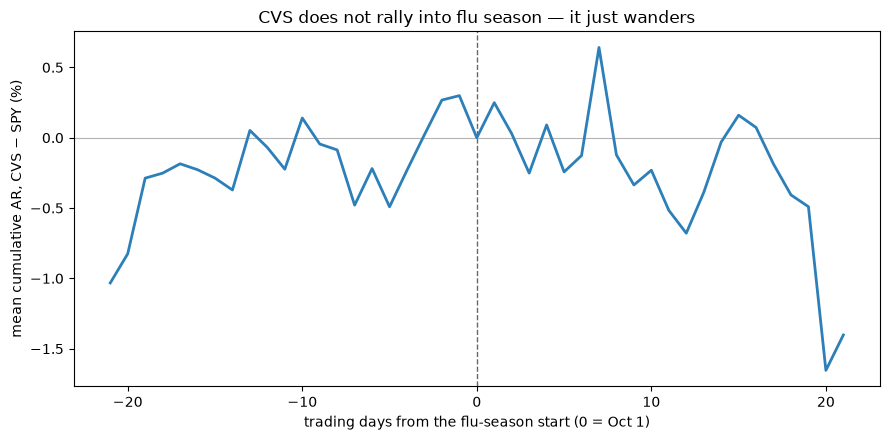

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#2c7fb8', lw=2)
ax.set_xlabel('trading days from the flu-season start (0 = Oct 1)')
ax.set_ylabel('mean cumulative AR, CVS − SPY (%)')
ax.set_title('CVS does not rally into flu season — it just wanders')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 2-week run-up | -0.08% | -0.11 | 9/19 |
| 1-month run-up | +1.12% | +1.02 | 11/19 |
| 2-week in-season | -0.23% | -0.23 | 10/19 |
| 1-month in-season | -1.40% | -0.91 | 8/19 |

Every cut is indistinguishable from noise: the 2-week run-up is essentially zero (-0.08%, *t* = -0.11), and the biggest number in the table (+1.12% at a month) still only makes *t* = +1.02. No rally-in, no give-back.

In [4]:
rows = [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk in-season','post_s'),('1mo in-season','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<14s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

2wk run-up     n=19  mean=-0.078%  t=-0.109  hit 9/19
1mo run-up     n=19  mean=+1.124%  t=+1.018  hit 11/19
2wk in-season  n=19  mean=-0.231%  t=-0.225  hit 10/19
1mo in-season  n=19  mean=-1.402%  t=-0.909  hit 8/19


## So what?

The famous *buy the drugstores into flu season* trade is folklore: CVS's abnormal return into and through the CDC-defined October season start looks like any random two-week window. Verdict: **None signal, Mirage tradability.** The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control.